# » `Dependencias`:

In [ ]:
# !pip install plotly
# %pip install sqlalchemy
# %pip install numpy
# %pip install matplotlib

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import re
import matplotlib.pyplot as plt
# import cufflinks as cf
# from IPython.display import display, HTML

# cf.set_config_file

## 1. Conección → SIM(172.27.0.124)

In [2]:
# spring.datasource.url = jdbc:sqlserver://172.27.250.27;databaseName=SIRIM
SERVER = '172.27.0.124' # '172.27.0.242'
#DRIVER = 'SQL Server Native Client 11.0'
DRIVER = 'ODBC Driver 17 for SQL Server'
DATABASE = 'SIM'
USERNAME = 'userestadistica' # 'udesa'
PASSWORD = '$Us3R_3sT4d1sTic4$' # 'DESARROLLO2006'
DATABASE_CONNECTION = f'mssql://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}?driver={DRIVER}'

engine = create_engine(DATABASE_CONNECTION)
connection = engine.connect()

## 2. Métodos genérico:

In [3]:
def get_query_sql(query):
    df = pd.read_sql(query, connection)
    return df

## 3. Visualización de datos: `INF-ENE2025`

### 3.1 Se define como regla de calidad, que la fecha de nacimiento del pasajero no debe ser mayor a la fecha de control migratorio.

In [13]:
df_1 = pd.read_excel('./data/A1.xlsx')

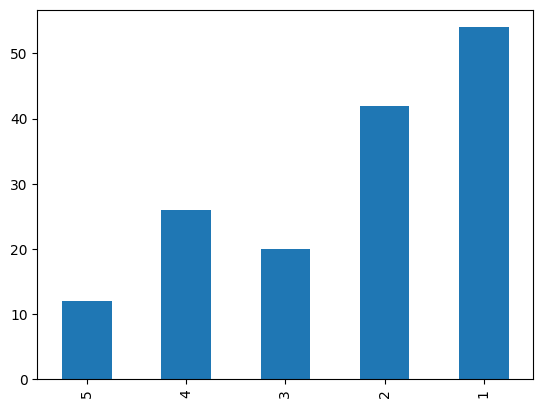

In [17]:
# ['Fecha Nacimiento', 'Nacionalidad', 'Dependencia', 'Fecha Control', 'Tipo Movimiento', 'Pais Mov', 'Via Transporte']

df_1['nDiferencia(Dias)'] = pd.to_datetime(df_1['Fecha Nacimiento']).dt.year - pd.to_datetime(df_1['Fecha Control']).dt.year

df_1_f = df_1.groupby(by=['nDiferencia(Dias)']).agg({ 'Id Persona': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_index(ascending=False) \
             .head(5)

df_1_f = df_1_f.plot.bar(legend=False, xlabel='')


### 3.2. Se define como regla de calidad, que los ciudadanos nacionalizados peruanos no deben iniciar trámites que les otorguen una calidad migratoria o un proceso de regularización tras su nacionalización.

In [18]:
df_2 = pd.read_excel('./data/A2.xlsx')

<Axes: >

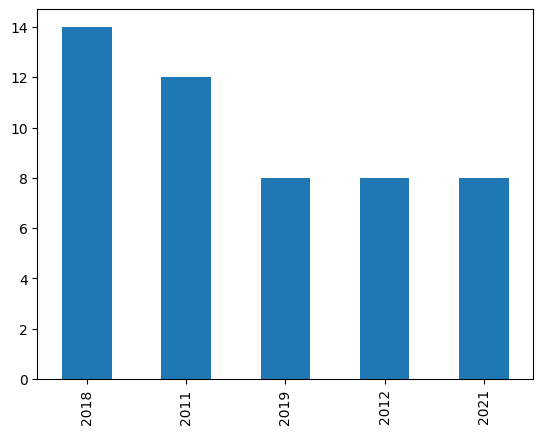

In [20]:
# ['Numero Trámite', 'Estado Trámite', 'Tipo Nacionalización', 'Fecha Trámite', 'Fecha Entrega Título', 'Trámites de Inmigración']

df_2['nAñoTitulo'] = pd.to_datetime(df_2['Fecha Entrega Título']).dt.year

df_2_f = df_2.groupby(by=['nAñoTitulo']).agg({ 'Id Persona': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_2_f.plot.bar(legend=False, xlabel='')


### 3.3 Se define como regla de calidad que los países asociados al continente europeo no deberán registrar movimientos migratorios de salida a través del transporte fluvial.

In [21]:
df_3 = pd.read_excel('./data/A3.xlsx')

<Axes: >

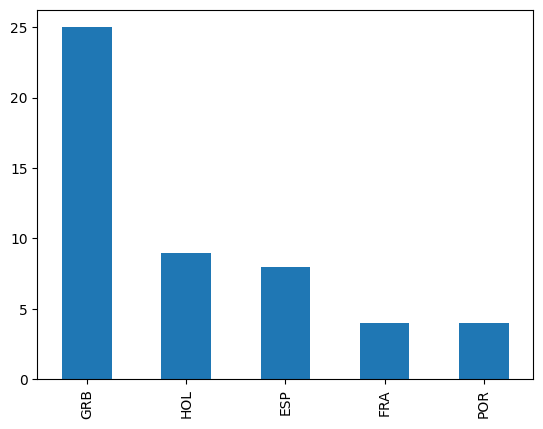

In [23]:
# ['Fecha Control', 'Via Transporte', 'Pais Movimiento', 'Dependencia']

df_3_f = df_3.groupby(by=['Pais Movimiento']).agg({ 'Id Persona': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_3_f.plot.bar(legend=False, xlabel='')
